<a href="https://colab.research.google.com/github/nishachari-here/Bonded/blob/main/planet_satellite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np

G = 6.674e-11

class Planet:
    def __init__(self, mass, position=np.array([0.0, 0.0, 0.0])):
        self.mass = mass
        self.position = position

class Satellite:
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = np.array(position, dtype=float)
        self.velocity = np.array(velocity, dtype=float)



In [21]:
def calculate_gravity(satellite, planet):
    r_vec = planet.position - satellite.position
    r_mag = np.linalg.norm(r_vec)
    if r_mag == 0:
        return np.array([0.0, 0.0, 0.0])  # Avoid division by zero
    force_mag = (G * satellite.mass * planet.mass) / (r_mag**2)
    force_vec = force_mag * (r_vec / r_mag)  # Direction towards the planet
    return force_vec

def update_velocity(satellite, force, delta_t):
    acceleration = force / satellite.mass
    satellite.velocity += acceleration * delta_t

def update_position(satellite, delta_t):
    satellite.position += satellite.velocity * delta_t




In [22]:
#planet = Planet(mass=5.972e24)  # Earth's mass
#satellite = Satellite(mass=7.347e22, position=[3.844e8, 0, 0], velocity=[0, 1018.28, 0]) # Example initial conditions
planet=Planet(1.989e30)
satellite = Satellite(mass=7.347e22, position=[3.844e8, 0, 0], velocity=[0, 1018.28, 0])
time = 0
delta_t = 86400/2  # Time step (seconds)
duration = 86400 * 14# Simulate for 2 days

# Simulation loop
positions = []
while time < duration:
    positions.append(satellite.position.copy())
    print(positions)
    gravity_force = calculate_gravity(satellite, planet)
    print(gravity_force)

    update_velocity(satellite, gravity_force, delta_t)
    update_position(satellite, delta_t)
    time += delta_t



[array([3.844e+08, 0.000e+00, 0.000e+00])]
[-1.9817519e+20  0.0000000e+00  0.0000000e+00]
[array([3.844e+08, 0.000e+00, 0.000e+00]), array([3.79366075e+08, 4.39896960e+07, 0.00000000e+00])]
[-1.99433588e+20 -2.31254808e+19  0.00000000e+00]
[array([3.844e+08, 0.000e+00, 0.000e+00]), array([3.79366075e+08, 4.39896960e+07, 0.00000000e+00]), array([3.69266260e+08, 8.73919727e+07, 0.00000000e+00])]
[-1.97895026e+20 -4.68345975e+19  0.00000000e+00]
[array([3.844e+08, 0.000e+00, 0.000e+00]), array([3.79366075e+08, 4.39896960e+07, 0.00000000e+00]), array([3.69266260e+08, 8.73919727e+07, 0.00000000e+00]), array([3.54139637e+08, 1.29604586e+08, 0.00000000e+00])]
[-1.93368245e+20 -7.07670326e+19  0.00000000e+00]
[array([3.844e+08, 0.000e+00, 0.000e+00]), array([3.79366075e+08, 4.39896960e+07, 0.00000000e+00]), array([3.69266260e+08, 8.73919727e+07, 0.00000000e+00]), array([3.54139637e+08, 1.29604586e+08, 0.00000000e+00]), array([3.34101192e+08, 1.70019618e+08, 0.00000000e+00])]
[-1.85711678e+20 -

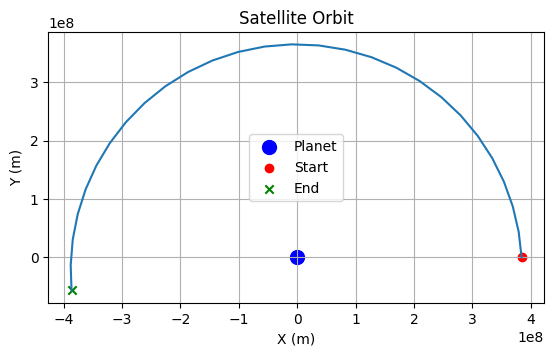

In [23]:
# You can then visualize the 'positions' list
import matplotlib.pyplot as plt
positions_array = np.array(positions)
plt.plot(positions_array[:, 0], positions_array[:, 1])
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Satellite Orbit")
plt.gca().set_aspect('equal', adjustable='box')
plt.scatter(planet.position[0], planet.position[1], color='blue', s=100, label='Planet')
plt.scatter(positions_array[0, 0], positions_array[0, 1], color='red', marker='o', label='Start')
plt.scatter(positions_array[-1, 0], positions_array[-1, 1], color='green', marker='x', label='End')
plt.legend()
plt.grid(True)
plt.show()